<a href="https://colab.research.google.com/github/SoumajyotiDhut/rare-disease-identification-system/blob/main/notebooks/colab/Day_9_GAN_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SetUP**

In [1]:
from google.colab import drive, userdata
import os, json, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

drive.mount('/content/drive')

try:
    os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
    print("✓ HF Token set")
except:
    print("⚠ No HF Token")

BASE    = "/content/drive/MyDrive/rare_disease_project"
DATA    = f"{BASE}/data"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"
GAN_DIR = f"{BASE}/gan"

os.makedirs(GAN_DIR,           exist_ok=True)
os.makedirs(f"{GAN_DIR}/generated", exist_ok=True)
os.makedirs(f"{GAN_DIR}/checkpoints", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {torch.cuda.get_device_name(0)}")
print(f"✓ GAN dir: {GAN_DIR}")

Mounted at /content/drive
✓ HF Token set
✓ Device: Tesla T4
✓ GAN dir: /content/drive/MyDrive/rare_disease_project/gan


# **Identify Ultra-Rare Classes**

In [2]:
import ast
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(f"{DATA}/clean_multimodal_samples.csv")

# Encode labels
new_le = LabelEncoder()
df['label'] = new_le.fit_transform(df['disease_name'])

# Count samples per class
class_counts = df.groupby(['label', 'disease_name']).size().reset_index(name='count')
class_counts = class_counts.sort_values('count')

# Define tiers
ultra_rare = class_counts[class_counts['count'] <= 5]
rare       = class_counts[(class_counts['count'] > 5) &
                           (class_counts['count'] <= 20)]
common     = class_counts[class_counts['count'] > 20]

print("=" * 55)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 55)
print(f"  Ultra-rare (≤5 samples) : {len(ultra_rare)} diseases")
print(f"  Rare (6-20 samples)     : {len(rare)} diseases")
print(f"  Common (>20 samples)    : {len(common)} diseases")

print(f"\nBottom 15 ultra-rare classes:")
print(ultra_rare[['disease_name', 'count']].head(15).to_string(index=False))

print(f"\nTop 10 GAN targets (5-20 samples — sweet spot):")
gan_targets = class_counts[(class_counts['count'] >= 5) &
                             (class_counts['count'] <= 20)]
print(gan_targets[['disease_name', 'count']].head(10).to_string(index=False))

# Save GAN targets
gan_target_labels = gan_targets['label'].tolist()
print(f"\n✓ GAN targets identified: {len(gan_target_labels)} classes")

CLASS DISTRIBUTION ANALYSIS
  Ultra-rare (≤5 samples) : 582 diseases
  Rare (6-20 samples)     : 403 diseases
  Common (>20 samples)    : 389 diseases

Bottom 15 ultra-rare classes:
                                                                                      disease_name  count
                                                                 16p13.3 microduplication syndrome      1
                                                            X-linked progressive cerebellar ataxia      1
X-linked intellectual disability-Dandy-Walker malformation-basal ganglia disease-seizures syndrome      1
                                                     X-linked intellectual disability, Snyder type      1
                                                                               Zebra body myopathy      1
                                                                           Wieacker-Wolff syndrome      1
                                                                      3-hydr

# **FastGAN Architecture**

In [3]:
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(channels)
        )
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.act(x + self.conv(x))

class FastGANGenerator(nn.Module):
    """Lightweight generator for few-shot image synthesis"""
    def __init__(self, nz=128, ngf=64, img_size=64):
        super().__init__()
        self.nz = nz

        self.init = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True)
        )

        self.upsample = nn.Sequential(
            # 4 → 8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            ResBlock(ngf*4),
            # 8 → 16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            ResBlock(ngf*2),
            # 16 → 32
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            ResBlock(ngf),
            # 32 → 64
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, self.nz, 1, 1)
        x = self.init(z)
        return self.upsample(x)


class FastGANDiscriminator(nn.Module):
    """Lightweight discriminator with spectral norm"""
    def __init__(self, ndf=64):
        super().__init__()

        def block(in_c, out_c, stride=2):
            return nn.Sequential(
                nn.utils.spectral_norm(
                    nn.Conv2d(in_c, out_c, 4, stride, 1, bias=False)),
                nn.LeakyReLU(0.2, inplace=True)
            )

        self.net = nn.Sequential(
            block(3,      ndf),      # 64 → 32
            block(ndf,    ndf*2),    # 32 → 16
            block(ndf*2,  ndf*4),    # 16 → 8
            block(ndf*4,  ndf*8),    # 8  → 4
            nn.Conv2d(ndf*8, 1, 4, 1, 0)  # 4 → 1
        )

    def forward(self, x):
        return self.net(x).view(-1)


# Test architecture
nz = 128
G = FastGANGenerator(nz=nz, ngf=64, img_size=64).to(device)
D = FastGANDiscriminator(ndf=64).to(device)

# Count parameters
g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())

print("✓ FastGAN architecture built")
print(f"  Generator params     : {g_params:,}")
print(f"  Discriminator params : {d_params:,}")

# Quick forward pass test
z_test   = torch.randn(4, nz).to(device)
fake_img = G(z_test)
d_out    = D(fake_img)

print(f"\nForward pass test:")
print(f"  Input noise shape    : {z_test.shape}")
print(f"  Generated img shape  : {fake_img.shape}")
print(f"  Discriminator output : {d_out.shape}")
print(f"  Image value range    : [{fake_img.min():.2f}, {fake_img.max():.2f}]")

✓ FastGAN architecture built
  Generator params     : 5,356,160
  Discriminator params : 2,763,777

Forward pass test:
  Input noise shape    : torch.Size([4, 128])
  Generated img shape  : torch.Size([4, 3, 64, 64])
  Discriminator output : torch.Size([4])
  Image value range    : [-1.00, 1.00]


# **GAN Dataset for One Class (Test)**

✓ Test GAN dataset built
  Disease : Waardenburg-Shah syndrome
  Label   : 1326
  Real samples: 15
  Original count: 5


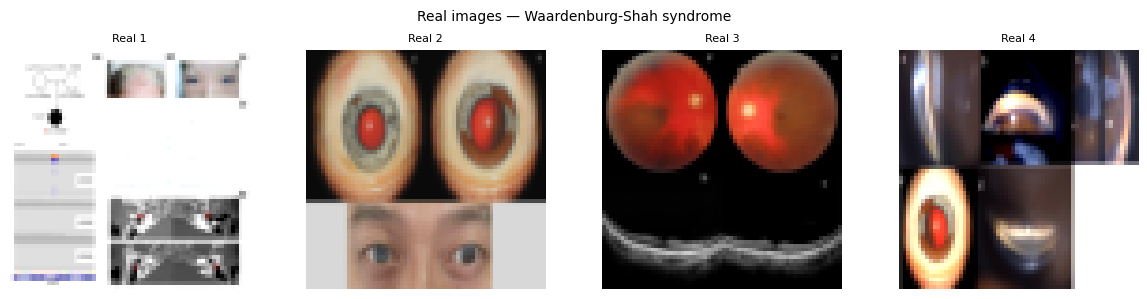

✓ Real samples plot saved


In [4]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class SingleClassGANDataset(Dataset):
    """Dataset for training GAN on a single disease class"""
    def __init__(self, df, disease_label, img_size=64):
        self.samples   = []
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])

        class_df = df[df['label'] == disease_label]
        for _, row in class_df.iterrows():
            try:
                images = row['images']
                if not isinstance(images, list):
                    images = eval(images)
                for img_info in images:
                    path = img_info['path']
                    if os.path.exists(path):
                        self.samples.append(path)
            except:
                continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        try:
            img = Image.open(
                self.samples[idx]).convert('RGB')
            return self.transform(img)
        except:
            return torch.zeros(3, 64, 64)


# Test on first GAN target class
test_label   = gan_targets['label'].iloc[0]
test_disease = gan_targets['disease_name'].iloc[0]
test_count   = gan_targets['count'].iloc[0]

test_dataset = SingleClassGANDataset(df, test_label)
test_loader  = DataLoader(test_dataset, batch_size=4,
                          shuffle=True)

print(f"✓ Test GAN dataset built")
print(f"  Disease : {test_disease}")
print(f"  Label   : {test_label}")
print(f"  Real samples: {len(test_dataset)}")
print(f"  Original count: {test_count}")

# Show sample real images
import matplotlib.pyplot as plt

if len(test_dataset) > 0:
    fig, axes = plt.subplots(1, min(4, len(test_dataset)),
                             figsize=(12, 3))
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    for i, ax in enumerate(axes):
        if i < len(test_dataset):
            img = test_dataset[i]
            # Denormalize
            img = (img * 0.5 + 0.5).permute(1, 2, 0).clamp(0,1)
            ax.imshow(img.numpy())
            ax.set_title(f"Real {i+1}", fontsize=8)
            ax.axis('off')

    plt.suptitle(f"Real images — {test_disease[:30]}",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{RESULTS}/day9_real_samples.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Real samples plot saved")

# **Train GAN on One Class (Proof of Concept)**

In [5]:
from torch.optim import Adam

def train_gan_one_class(
        G, D, dataloader, device,
        epochs=200, nz=128, lr=2e-4):
    """Train GAN on a single disease class"""

    opt_G = Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        g_loss_epoch = 0
        d_loss_epoch = 0
        batches = 0

        for real_imgs in dataloader:
            real_imgs = real_imgs.to(device)
            bs        = real_imgs.size(0)

            # ── Train Discriminator ─────────────────
            opt_D.zero_grad()

            # Real
            d_real  = D(real_imgs)
            loss_real = F.relu(1.0 - d_real).mean()

            # Fake
            z        = torch.randn(bs, nz).to(device)
            fake_imgs = G(z).detach()
            d_fake    = D(fake_imgs)
            loss_fake = F.relu(1.0 + d_fake).mean()

            d_loss = loss_real + loss_fake
            d_loss.backward()
            opt_D.step()

            # ── Train Generator ─────────────────────
            opt_G.zero_grad()
            z         = torch.randn(bs, nz).to(device)
            fake_imgs = G(z)
            g_loss    = -D(fake_imgs).mean()
            g_loss.backward()
            opt_G.step()

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()
            batches      += 1

        g_losses.append(g_loss_epoch / max(batches, 1))
        d_losses.append(d_loss_epoch / max(batches, 1))

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1:03d}/{epochs} | "
                  f"G: {g_losses[-1]:.4f} | "
                  f"D: {d_losses[-1]:.4f}")

    return g_losses, d_losses


# Reinitialize fresh models for training
G = FastGANGenerator(nz=nz, ngf=64).to(device)
D = FastGANDiscriminator(ndf=64).to(device)

print(f"Training GAN on: {test_disease}")
print(f"Real images available: {len(test_dataset)}")
print(f"Epochs: 200")
print("-" * 45)

g_losses, d_losses = train_gan_one_class(
    G, D, test_loader, device,
    epochs=200, nz=nz
)

print("-" * 45)
print("✓ GAN training complete")

Training GAN on: Waardenburg-Shah syndrome
Real images available: 15
Epochs: 200
---------------------------------------------
  Epoch 050/200 | G: 0.4520 | D: 2.2022
  Epoch 100/200 | G: 0.9148 | D: 1.2481
  Epoch 150/200 | G: 0.7927 | D: 1.2983
  Epoch 200/200 | G: 0.9129 | D: 0.7963
---------------------------------------------
✓ GAN training complete


# **Generate + Visualize Synthetic Images**

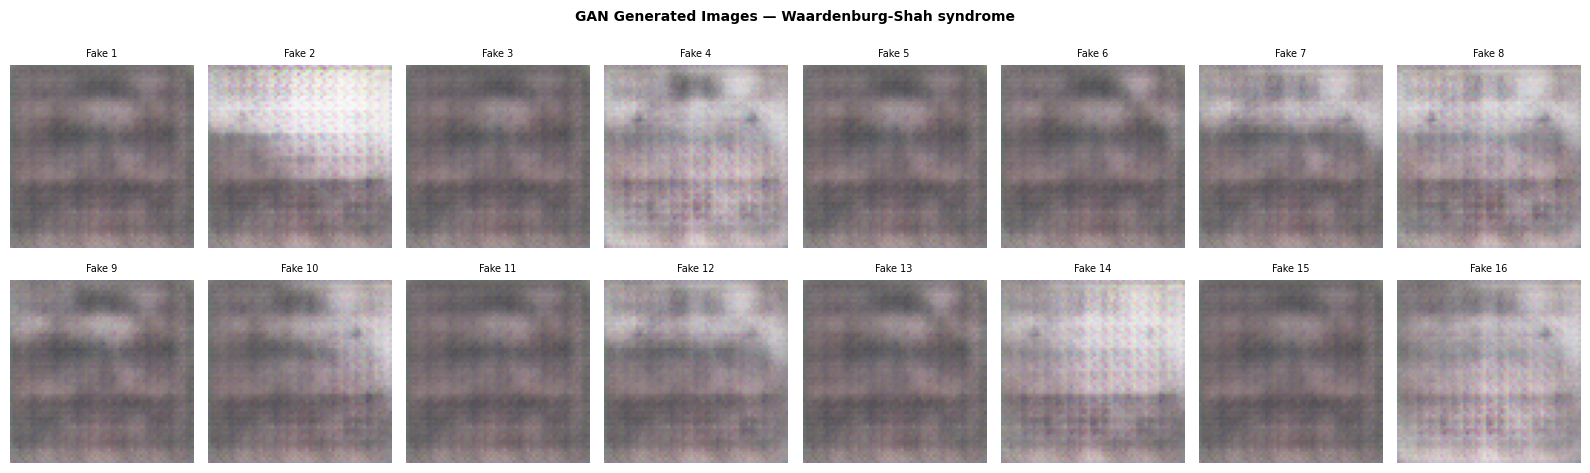

✓ Generated samples saved


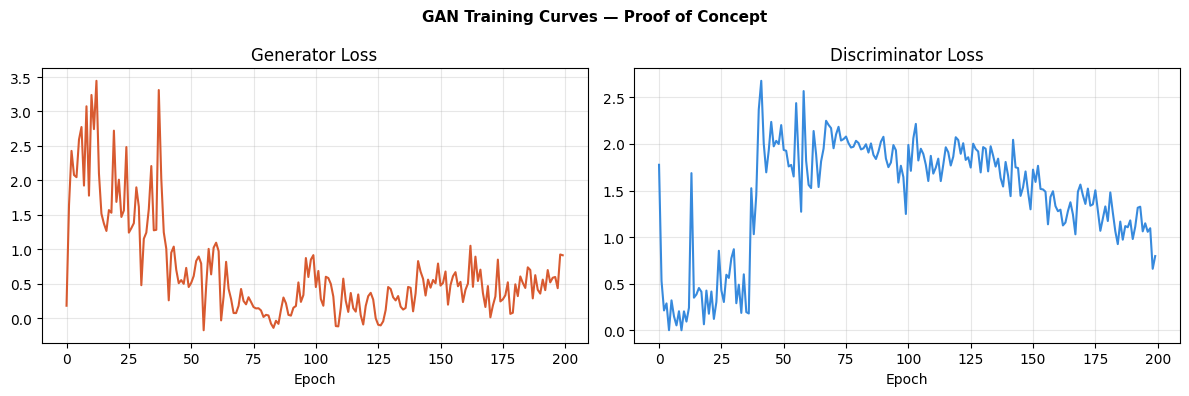

In [6]:
import torchvision

G.eval()
with torch.no_grad():
    z         = torch.randn(16, nz).to(device)
    fake_imgs = G(z)
    # Denormalize from [-1,1] to [0,1]
    fake_imgs = (fake_imgs * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
axes = axes.flatten()

for i in range(16):
    img = fake_imgs[i].cpu().permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Fake {i+1}", fontsize=7)

plt.suptitle(
    f"GAN Generated Images — {test_disease[:35]}",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{RESULTS}/day9_generated_samples.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Generated samples saved")

# Plot GAN training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(g_losses, color='#D85A30', linewidth=1.5)
axes[0].set_title('Generator Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(d_losses, color='#378ADD', linewidth=1.5)
axes[1].set_title('Discriminator Loss')
axes[1].set_xlabel('Epoch')
axes[1].grid(True, alpha=0.3)

plt.suptitle('GAN Training Curves — Proof of Concept',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RESULTS}/day9_gan_curves.png",
            dpi=150, bbox_inches='tight')
plt.show()

# **Save GAN + Day 9 Summary**

In [7]:
# Save GAN checkpoints
torch.save(G.state_dict(),
    f"{GAN_DIR}/checkpoints/generator_test.pt")
torch.save(D.state_dict(),
    f"{GAN_DIR}/checkpoints/discriminator_test.pt")
print("✓ GAN checkpoints saved")

summary = {
    "day"  : 9,
    "task" : "GAN architecture setup + proof of concept",
    "architecture": {
        "generator"    : "FastGAN with ResBlocks",
        "discriminator": "Spectral Norm Discriminator",
        "latent_dim"   : 128,
        "image_size"   : 64,
        "loss"         : "Hinge loss"
    },
    "test_class": {
        "disease"      : test_disease,
        "real_samples" : len(test_dataset),
        "epochs"       : 200
    },
    "gan_targets": {
        "total_classes": len(gan_target_labels),
        "criteria"     : "5-20 samples per class"
    },
    "status": "Day 9 complete — GAN architecture verified"
}

with open(f"{RESULTS}/day9_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 55)
print("DAY 9 COMPLETE ✓")
print("=" * 55)
print(f"  Architecture   : FastGAN + Spectral Norm Disc")
print(f"  Latent dim     : 128")
print(f"  Image size     : 64x64")
print(f"  Test class     : {test_disease[:35]}")
print(f"  Real samples   : {len(test_dataset)}")
print(f"  GAN targets    : {len(gan_target_labels)} classes")
print(f"\n  Next → Day 10: GAN training on HAM10000 (Kaggle)")

✓ GAN checkpoints saved

DAY 9 COMPLETE ✓
  Architecture   : FastGAN + Spectral Norm Disc
  Latent dim     : 128
  Image size     : 64x64
  Test class     : Waardenburg-Shah syndrome
  Real samples   : 15
  GAN targets    : 474 classes

  Next → Day 10: GAN training on HAM10000 (Kaggle)
